In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
GOAL = 100
p_h = 0.4

V = np.zeros(GOAL + 1)
V[GOAL] = 1.0
policy = np.zeros(GOAL + 1)

In [18]:
while True:
    delta = 0
    for s in range(1, GOAL):
        actions = range(1, min(s, GOAL - s) + 1)
        values = [
            p_h * V[s + a] + (1 - p_h) * V[s - a]
            for a in actions
        ]
        best = max(values)
        delta = max(delta, abs(V[s] - best))
        V[s] = best
    if delta < 1e-9:
        break

In [19]:
for s in range(1, GOAL):
    actions = range(1, min(s, GOAL - s) + 1)
    values = [
        p_h * V[s + a] + (1 - p_h) * V[s - a]
        for a in actions
    ]
    policy[s] = actions[np.argmax(values)]

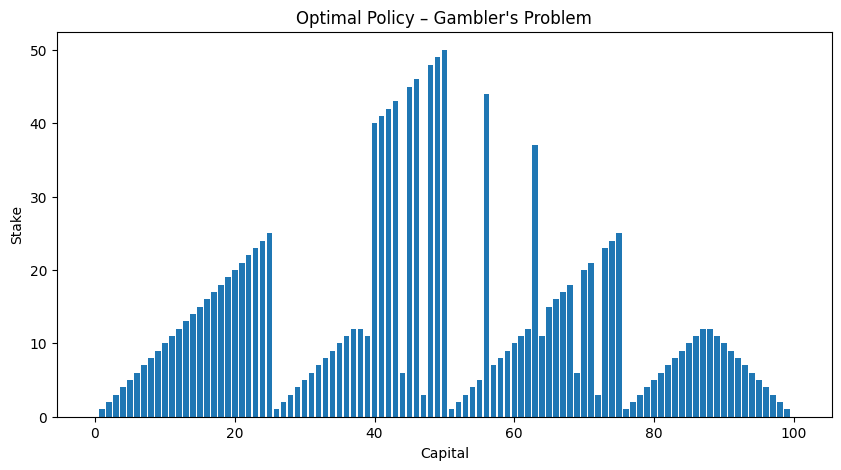

In [20]:
plt.figure(figsize=(10,5))
plt.bar(range(GOAL+1), policy)
plt.xlabel("Capital")
plt.ylabel("Stake")
plt.title("Optimal Policy – Gambler's Problem")
plt.show()